# KNN
# Mô hình

- KNN giả định rằng những dữ liệu tương đồng nhau sẽ nằm gần nhau trong không gian đặc trưng
- Khác với các mô hình khác, KNN là một thuật toán học lười và phi tham số. Nghĩa là nó không thực sự học một mô hình tổng quát từ dữ liệu huần luyện mà chỉ lưu trữ lại toàn bộ dữ liệu
- Quá trình tính toán chỉ diễn ra khi cần dữ đoán một điểm dữ liệu mới


# Bài toán áp dụng

Áp dụng cho Học có giám sát:
- Phân loại: Lấy theo đa số dự đoán làm kết quả cuối cùng
- Hồi quy: lấy trung bình các dự đoán làm dự đoán cuối cùng

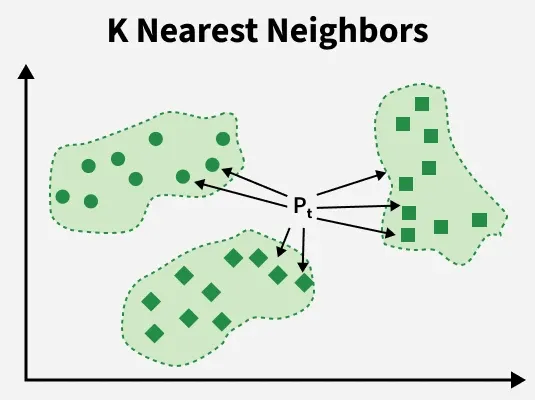

# Các bước thực hiện thuật toán

**B1**: lưu trữ toàn bộ dữ liệu huấn luyện ($X_{train}, y_{train}$). Xây dựng KD tree hoặc Ball tree nếu cần

**B2**: Chuẩn hóa các đặc trưng vê cùng thang đo dùng MinMaxScaler hoặc StandardScaler

**B3**: Với mỗi điểm test $x_q$:

- Tính khoảng cách từ $x_q$ đến tất cả điểm train (hoặc dùng KD-tree/Ball tree để tìm nhanh)
- Chọn ra K điểm gần nhất
  - Classification: vote theo nhãn xuất hiện nhiều nhất
  - Regression: lấy trung bình giá trị y của K láng giềng

# Cách lựa chọn tham số $K$

Ảnh hưởng của $K$ đến mô hình:
- Nếu $K$ quá nhỏ: mô hình sẽ dự đoán nhãn dựa trên điểm gần nhất, nếu gần điểm nhiễu, nó sẽ bỏ qua các điểm xung quanh mà dự đoán sai. Điều này dẫn đến hiện tượng quá khớp
- Nếu $K$ quá lớn: mô hình sẽ bỏ qua đặc trưng cục bộ mà dự đoán dựa trên xu hướng toàn cục dẫn đến hiện tượng chưa khớp

Cách tối ưu là dùng k-Fold-cross-validation


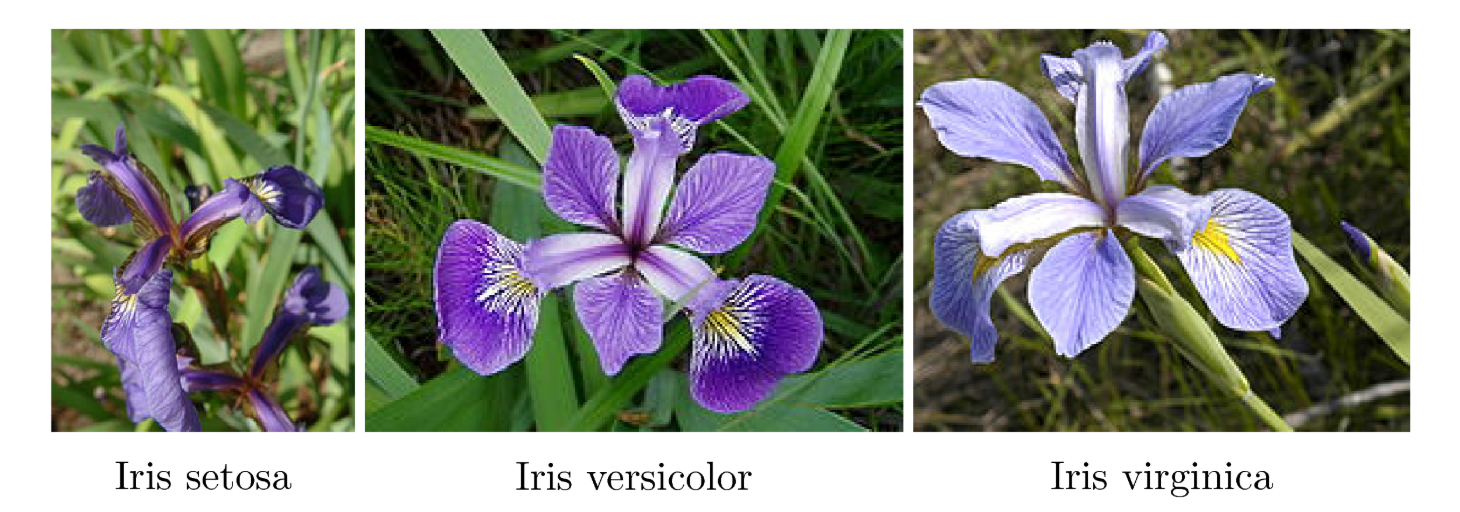

**Iris flower dataset**: Mỗi loại có 50 bông hoa được đo với dữ liệu là 4 thông tin: chiều dài, chiều rộng đài hoa (sepal), và chiều dài, chiều rộng cánh hoa (petal).

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import neighbors, datasets

iris = datasets.load_iris()

iris_X = iris.data
iris_y = iris.target

print("Number of classes: ", len(np.unique(iris_y)))
print("Number of data points: ", len(iris_y))

X0 = iris_X[iris_y == 0]

print("\nSamples of class 0:\n", X0[:5])

X1 = iris_X[iris_y == 1]
print("\nSamples of class 1:\n", X1[:5])

X2 = iris_X[iris_y == 2]
print("\nSamples of class 2:\n", X2[:5])


Number of classes:  3
Number of data points:  150

Samples of class 0:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

Samples of class 1:
 [[7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.9 1.5]
 [5.5 2.3 4.  1.3]
 [6.5 2.8 4.6 1.5]]

Samples of class 2:
 [[6.3 3.3 6.  2.5]
 [5.8 2.7 5.1 1.9]
 [7.1 3.  5.9 2.1]
 [6.3 2.9 5.6 1.8]
 [6.5 3.  5.8 2.2]]


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(iris_X, iris_y, test_size=50, random_state=42)

K tối ưu (5-fold CV trên tập train): 1


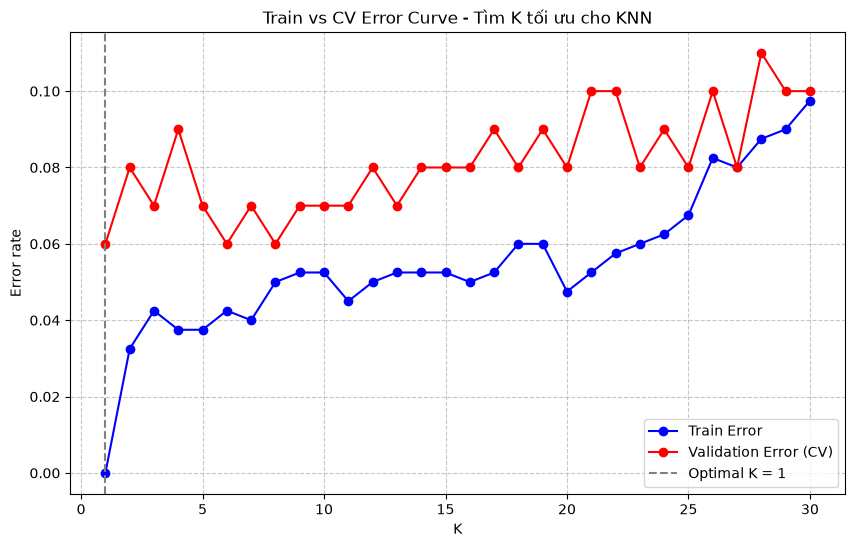

In [10]:
from sklearn.model_selection import cross_validate
from sklearn import neighbors
import numpy as np
import matplotlib.pyplot as plt

K_values = range(1, 31)
train_errors = []
val_errors = []

for k in K_values:
    clf = neighbors.KNeighborsClassifier(n_neighbors=k, p=2)
    cv_results = cross_validate(
        clf, X_train, y_train,
        cv=5, scoring='accuracy',
        return_train_score=True
    )
    train_errors.append(1 - cv_results['train_score'].mean())
    val_errors.append(1 - cv_results['test_score'].mean())

optimal_k = K_values[val_errors.index(min(val_errors))]
print(f"K tối ưu (5-fold CV trên tập train): {optimal_k}")

plt.figure(figsize=(10, 6))
plt.plot(K_values, train_errors, label='Train Error', marker='o', color='blue')
plt.plot(K_values, val_errors, label='Validation Error (CV)', marker='o', color='red')
plt.axvline(x=optimal_k, color='gray', linestyle='--', label=f'Optimal K = {optimal_k}')
plt.title('Train vs CV Error Curve - Tìm K tối ưu cho KNN')
plt.xlabel('K')
plt.ylabel('Error rate')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

clf = neighbors.KNeighborsClassifier(n_neighbors=optimal_k, p=2)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("acc: ", acc)
print("prec: ", prec)
print("recall: ", recall)
print("f1: ", f1)


acc:  0.98
prec:  0.9791666666666666
recall:  0.9791666666666666
f1:  0.978494623655914


# Chuẩn hoá dữ liệu (Feature Scaling)

KNN dựa hoàn toàn vào khoảng cách giữa các điểm nên **rất nhạy cảm với thang đo** của từng đặc trưng: đặc trưng nào có khoảng giá trị lớn hơn sẽ áp đảo các đặc trưng còn lại trong công thức khoảng cách, bất kể mức độ liên quan thực sự đến nhãn.

- **StandardScaler**: $x' = \dfrac{x - \mu}{\sigma}$ — đưa về phân phối có trung bình 0, phương sai 1. Phù hợp khi dữ liệu xấp xỉ phân phối chuẩn.
- **MinMaxScaler**: $x' = \dfrac{x - x_{min}}{x_{max} - x_{min}}$ — đưa về $[0, 1]$. Phù hợp khi không giả định phân phối, nhưng nhạy với outlier.

# Weighted KNN

Ở KNN cơ bản, cả $K$ láng giềng đóng góp **như nhau** vào kết quả bầu chọn/trung bình. Điều này có thể không hợp lý: một điểm cách $x_q$ 0.1 đơn vị không nên có tiếng nói ngang bằng một điểm cách 9 đơn vị.

**Weighted KNN** gán trọng số theo nghịch đảo khoảng cách:

$$w_i = \frac{1}{d(x_q, x_i) + \epsilon}, \quad \text{hoặc} \quad w_i = \frac{1}{d(x_q, x_i)^2 + \epsilon}$$

($\epsilon$ nhỏ để tránh chia cho 0 khi $x_i = x_q$)

- **Classification**: nhãn dự đoán là nhãn có tổng trọng số lớn nhất: $\hat{y} = \arg\max_c \sum_{i: y_i = c} w_i$
- **Regression**: $\hat{y} = \dfrac{\sum_i w_i y_i}{\sum_i w_i}$

Weighted KNN thường **ít nhạy với việc chọn K** hơn (K lớn vẫn ổn vì các điểm xa đóng góp gần như không đáng kể), nhưng vẫn không giải quyết được vấn đề nhiễu ở các điểm rất gần.

# Độ đo khoảng cách

## Khoảng cách Euclid

$$d = \sqrt{\sum_{i=1}^{n}(x_i-y_i)^2}$$
- Đặc điểm: Lấy bình phương sự chênh lệch nên phạt nặng các điểm có sự khác biệt lớn ở bất cứ một chiều đặc trưng nào
- Tốt nhất cho dữ liệu có các đặc trưng liên tục và có thang đo tương đồng nhau

## Khoảng cách Manhattan

$$d = \sum_{i=1}^{n}|x_i-y_i|$$
- Đặc điểm: Nó chỉ lấy giá trị tuyệt đối của sự chênh lệch. Do đó ít bị ảnh hưởng bởi các giá trị ngoại lai (outliers) hơn so với Euclid
- Hiệu quả khi tập dữ liệu của bạn có cực kỳ nhiều chiều (high-dimensional data) hoặc khi dữ liệu chứa nhiều nhiễu và điểm dị thường

## Khoảng cách Minkowski

$$d = \left( \sum_{i=1}^{n} \vert{}x_i - y_i\vert{}^p \right)^{\frac{1}{p}}$$
- Nếu $p = 1$: Minkowski trở thành khoảng cách Manhattan
- Nếu $p = 2$: Minkowski trở thành khoảng cách Euclidean
- Nếu $p = \infty$: Trở thành khoảng cách Chebyshev.
Là độ đo mặc định trong scikit-learn

## Khoảng cách Chebyshev

$d = \max_{i} (\vert{}x_i - y_i\vert{})$
- Ít phổ biến hơn
- Dùng trong các bài toán mà lỗi ở một đặc trưng bất kỳ quyết định lớn đến kết quả
- Tương ứng trường hợp giới hạn p → ∞ của Minkowski distance

## Khoảng cách Hamming

- Nó đếm số lượng vị trí mà hai mẫu dữ liệu có giá trị khác nhau.
- Có thể dùng để tính số đặc trưng khác nhau giữa hai dòng dữ liệu sau khi đã biến đổi one-hot-encoding
- So sánh chuỗi có độ dài bằng nhau như ADN hoặc vân tay

## Cosine similarity

$$\text{Cosine Similarity} = \frac{A \cdot B}{\Vert{}A\Vert{} \Vert{}B\Vert{}}$$
- Đặc điểm: Nếu góc giữa hai vector là 0 độ (trùng hướng), độ tương đồng là lớn nhất. Nếu góc là 90 độ, chúng hoàn toàn không liên quan.
- Cực kỳ phổ biến trong Phân tích xử lý ngôn ngữ tự nhiên (NLP) và Hệ thống gợi ý (Recommender Systems). Ví dụ: Đếm tần suất từ vựng của hai văn bản xem chúng có chung chủ đề không, bất kể văn bản này dài 100 từ hay 100.000 từ.


# KD tree

- Là một cây tìm kiếm nhị phân với mỗi node là một điểm trong không gian $k$ chiều
- Môi nút của cây chia không gian thành 2 phần trái và phải

**Ví dụ**:  (3, 6), (17, 15), (13, 15), (6, 12), (9, 1), (2, 7), (10, 19)

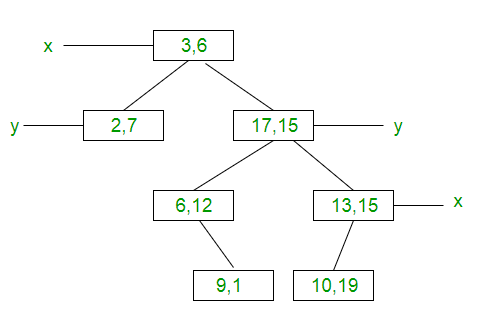

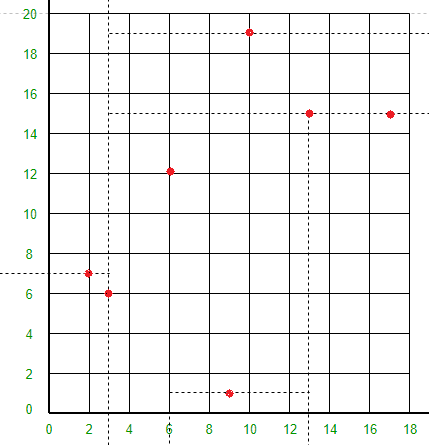

- Duy trì một priority-queue (max-heap) gồm k phần tử có khoảng cách đến điểm đó là nhỏ nhất
- Duyệt từ gốc đến lá rồi đệ quy ngược lên, xét xem có cần xét nhánh xa hay có thể tỉa nhánh

Ví dụ điểm (8,8)

| Nút hiện tại | $d$ tới Target | Trục cắt | $d_{plane}$ tới Trục | $d_{best}$ hiện tại | Điểm gần nhất hiện tại (Max-Heap) | Hướng đi tiếp (Nhánh gần) | Quyết định với Nhánh xa |
| --- | --- | --- | --- | --- | --- | --- | --- |
| **(3, 6)** | $5.4$ | $x=3$ | $\vert{}8-3\vert{} = 5$ | $\infty$ | (3, 6) | Sang Phải $\rightarrow$ (17, 15) | $5 < \infty \rightarrow$ Lưu lại (2, 7) chờ xét |
| **(17, 15)** | $11.4$ | $y=15$ | $\vert{}8-15\vert{} = 7$ | $\infty$ | (3, 6), (17, 15) | Sang Trái $\rightarrow$ (6, 12) | $7 < \infty \rightarrow$ Lưu lại (13, 15) chờ xét |
| **(6, 12)** | $4.5$ | $x=6$ | $\vert{}8-6\vert{} = 2$ | **$11.4$** | (6, 12), (3, 6), (17, 15) | Sang Phải $\rightarrow$ (9, 1) | Không có nhánh trái $\rightarrow$ Bỏ qua |
| **(9, 1)** | $7.1$ | $y=1$ | $\vert{}8-1\vert{} = 7$ | **$7.1$** | (6, 12), (3, 6), (9, 1) | Nút lá, bắt đầu Backtrack | Không có nhánh con |
| **(17, 15)** *(Backtrack)* | - | $y=15$ | $7$ | $7.1$ | (6, 12), (3, 6), (9, 1) | - | $7 < 7.1 \rightarrow$ **Bắt buộc** xét (13, 15) |
| **(13, 15)** | $8.6$ | $x=13$ | $\vert{}8-13\vert{} = 5$ | $7.1$ | (6, 12), (3, 6), (9, 1) | Sang Trái $\rightarrow$ (10, 19) | Không có nhánh phải $\rightarrow$ Bỏ qua |
| **(10, 19)** | $11.2$ | $y=19$ | $\vert{}8-19\vert{} = 11$ | $7.1$ | (6, 12), (3, 6), (9, 1) | Nút lá, bắt đầu Backtrack | Không có nhánh con |
| **(3, 6)** *(Backtrack)* | - | $x=3$ | $5$ | $7.1$ | (6, 12), (3, 6), (9, 1) | - | $5 < 7.1 \rightarrow$ **Bắt buộc** xét (2, 7) |
| **(2, 7)** | $6.1$ | $y=7$ | $\vert{}8-7\vert{} = 1$ | **$6.1$** | (6, 12), (3, 6), (2, 7) | Nút lá, bắt đầu Backtrack | Không có nhánh con |


# Ball tree
- Mỗi nút của cây là một hình cầu được xác định bởi tâm $c$ và bán kính $r$ sao cho mọi điểm thuộc nút đó đều nằm trong hình cầu này
- Các bước xây cây:
  - Tìm điểm $x_a$ xa nhất so với 1 điểm bất kỳ, rồi tìm $x_b$ xa nhất so với $x_a$ → trục chia là hướng $x_b$ - $x_a$
  - Chiếu tất cả điểm trong $S$ lên trục vừa chọn, sắp xếp theo giá trị chiếu $proj(x) = x · u$, chia tại median thành hai tập $S_{left}$ và $S_{right}$ có kích thước gần bằng nhau (đảm bảo cây cân bằng).
  - Đệ quy xây hai cây con
    
    ```left_child  = build(S_left)```
    
    ```right_child = build(S_right)```

  - Xây nút hiện tại:
    - Tâm c: có thể lấy trung bình tất cả điểm trong S,
    - Bán kính $r = max(||x - c||)$ với mọi $x ∈ S$
      
    Trả về node gồm ```(center, radius, left_child, right_child)```

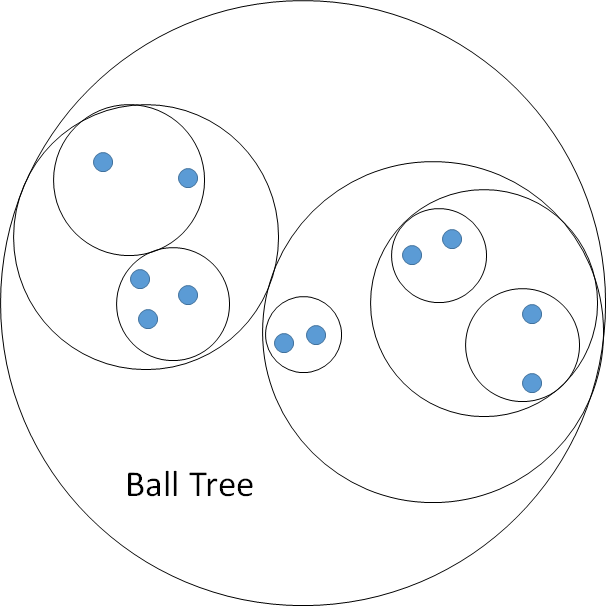

Tìm kiếm k-NN:
Duy trì max-heap (pq) lưu k điểm gần nhất với q, worst_dist = dist tại đỉnh pq


 search(node, q):
 
    d = ||q - node.center||
    nếu pq đủ k phần tử VÀ d - node.radius > worst_dist:
        return  # cắt tỉa, bỏ qua cả node này

    nếu node là leaf:
        với mỗi điểm x trong node:
            nếu pq chưa đủ k: thêm x vào pq
            ngược lại nếu dist(q,x) < worst_dist: thay điểm ở đỉnh pq bằng x
    ngược lại (internal node):
        đệ quy vào nhánh có center gần q hơn TRƯỚC, nhánh kia sau
        (mỗi lần vào node con đều lặp lại kiểm tra pruning ở đầu)


# Curse of dimensionality
- khi số chiều $d$ tăng, hiệu quả cắt tỉa (pruning) của KD-tree và Ball tree giảm mạnh — với $d$ đủ lớn (thường > vài chục chiều), gần như mọi nhánh đều phải được xét, khiến chúng suy biến về độ phức tạp tương đương brute-force nhưng lại tốn thêm overhead xây cây.
- Nguyên nhân sâu xa: trong không gian chiều cao, khoảng cách giữa điểm gần nhất và xa nhất tới một điểm truy vấn có xu hướng **hội tụ về nhau**
- Cách xử lý:
  - Lựa chọn đặc trưng, vứt bỏ những đặc trưng nhiễu hoặc không liên quan
  - Giảm chiều dữ liệu

# Tổng kết

## Ưu điểm
- Đơn giản, dễ hiểu, dễ diễn giải kết quả
- Không giả định gì về phân phối dữ liệu (non-parametric)
- Không có giai đoạn huấn luyện tốn kém — dễ cập nhật khi có dữ liệu mới (chỉ cần thêm vào tập lưu trữ)
- Ranh giới quyết định linh hoạt, có thể mô hình hoá quan hệ phi tuyến phức tạp
- Dùng được cho cả classification và regression

## Nhược điểm
- **Chậm khi dự đoán** với $n$ lớn (brute-force $O(nd)$ mỗi query); KD-tree/Ball-tree giảm thiểu nhưng suy biến ở chiều cao (curse of dimensionality)
- **Tốn bộ nhớ**: phải lưu toàn bộ dữ liệu train
- **Nhạy cảm với thang đo đặc trưng** — bắt buộc phải chuẩn hoá
- **Nhạy cảm với outlier và nhiễu**, đặc biệt khi K nhỏ
- **Nhạy cảm với dữ liệu mất cân bằng (imbalanced)**: lớp đa số dễ áp đảo trong vote, kể cả khi điểm truy vấn gần lớp thiểu số hơn
- Không cho biết đặc trưng nào quan trọng (không có feature importance như Decision Tree)

## Khi nào nên dùng KNN
Phù hợp với dữ liệu nhỏ/vừa, số chiều thấp, ranh giới quyết định không tuyến tính, và khi cần một baseline nhanh, dễ diễn giải trước khi thử các mô hình phức tạp hơn.